## Downloading and becoming one with the data

In [2]:
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
zpi_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")
zpi_ref.extractall()
zpi_ref.close()

--2025-05-28 15:05:54--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.193.207, 173.194.194.207, 173.194.195.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.193.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M   217MB/s    in 0.7s    

2025-05-28 15:05:55 (217 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [3]:
import os

for (root,dirs,files) in os.walk("10_food_classes_10_percent"):
  print(f"There are {len(dirs)} directories and {len(files)} images in '{root}'.")

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/tra

In [4]:
import tensorflow as tf

IMAGE_SHAPE = (224,224)
BATCH_SIZE = 32

train_dir = "10_food_classes_10_percent/train"
test_dir = "10_food_classes_10_percent/test"

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE
    )

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    shuffle=False
    )

class_names = train_data.class_names

# Optional: improve performance with prefetching
train_data = train_data.prefetch(buffer_size=tf.data.AUTOTUNE)
test_data = test_data.prefetch(buffer_size=tf.data.AUTOTUNE)

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(lambda x,y: (normalization_layer(x),y))
test_data = test_data.map(lambda x,y: (normalization_layer(x),y))



Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


## Setting up callbacks

* https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/TensorBoard

In [5]:
import datetime
def create_tensorboard_callback(dir_name, experiment_name):
  log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  tensorboard_callback = tf.keras.callbacks.TensorBoard(
      log_dir=log_dir
  )
  print(f"Saving TensorBoard log files to: {log_dir}")
  return tensorboard_callback

## Creating models using TensorFlow Hub

* https://www.tensorflow.org/hub
* https://www.kaggle.com/models
* https://paperswithcode.com/
* https://paperswithcode.com/sota

In [6]:
# Let' compare the following two models:
resnet_url = "https://tfhub.dev/google/imagenet/resnet_v2_50/feature_vector/5"
efficientnet_url = "https://tfhub.dev/google/imagenet/efficientnet_v2_imagenet21k_b0/feature_vector/2"

In [7]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

def create_model(model_url, num_classes = 10):
  """Takes a TensorFlow Hub URL and creates a Keras Sequential model with it.

  Args:
    model_url (str): A TensorFlow Hub feature extraction URL.
    num_classes (int): Number of output neurons in output layer,
      should be equal to number of target classes, default 10.

  Returns:
    An uncompiled Keras Sequential model with model_url as feature
    extractor layer and Dense output layer with num_classes outputs.
  """

  # Download the pretrained model and save it as a Keras layer
  feature_extractor_layer = hub.KerasLayer(model_url,
                                          trainable=False, # freeze the already learned patterns
                                          name='feature_extractor_layer',
                                          input_shape=IMAGE_SHAPE + (3,)) # define the input image shape (224,224,3)


  # Create our own model
  model = Sequential([
      tf.keras.layers.Lambda(lambda x: feature_extractor_layer(x)), # use the feature extraction layer as the base
      # Lambda uasge is a solution for "ValueError: Only instances of keras.Layer can be added to a Sequential model.
      # Received: <tensorflow_hub.keras_layer.KerasLayer object at 0x7a9a39daf130> (of type <class 'tensorflow_hub.keras_layer.KerasLayer'>)"
      Dense(num_classes, activation='softmax', name='output_layer') # create our own output layer
  ])

  return model

In [9]:
# Create a model
resnet_model = create_model(resnet_url, num_classes=len(class_names))

# Compile
resnet_model.compile(loss="sparse_categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])

In [8]:
len(class_names)

10

In [10]:
len(test_data)

79

In [11]:
# Fit the model
resnet_history = resnet_model.fit(train_data,
                                  epochs=5,
                                  validation_data=test_data,
                                  validation_steps=len(test_data),
                                  callbacks=[create_tensorboard_callback("training_logs", "resnet50V2")])

Saving TensorBoard log files to: training_logs/resnet50V2/20250528-150607
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 526s 22s/step - accuracy: 0.2805 - loss: 2.1621 - val_accuracy: 0.6280 - val_loss: 1.1756
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 602s 24s/step - accuracy: 0.7178 - loss: 0.9907 - val_accuracy: 0.7256 - val_loss: 0.8344
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 561s 24s/step - accuracy: 0.8122 - loss: 0.6384 - val_accuracy: 0.7544 - val_loss: 0.7438
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 563s 24s/step - accuracy: 0.8832 - loss: 0.4894 - val_accuracy: 0.7712 - val_loss: 0.6926
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 561s 24s/step - accuracy: 0.9039 - loss: 0.3795 - val_accuracy: 0.7804 - val_loss: 0.6676


<Axes: >

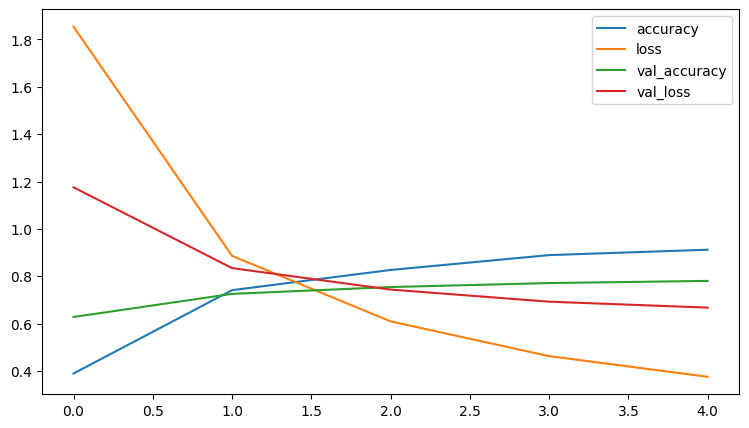

In [12]:
import pandas as pd
pd.DataFrame(resnet_history.history).plot(figsize=(9, 5))

In [13]:
resnet_history.history

{'accuracy': [0.3893333375453949,
  0.7413333058357239,
  0.8266666531562805,
  0.8893333077430725,
  0.9120000004768372],
 'loss': [1.8537182807922363,
  0.8861162662506104,
  0.6094526648521423,
  0.4626748859882355,
  0.37543928623199463],
 'val_accuracy': [0.628000020980835,
  0.725600004196167,
  0.7544000148773193,
  0.7712000012397766,
  0.7803999781608582],
 'val_loss': [1.1756356954574585,
  0.834418773651123,
  0.7437970638275146,
  0.6925877928733826,
  0.6675711274147034]}

In [14]:
resnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,472 (240.13 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 40,982 (160.09 KB)

In [16]:
test_data_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    shuffle=False
    )

Found 2500 files belonging to 10 classes.


(np.float64(-0.5), np.float64(383.5), np.float64(511.5), np.float64(-0.5))

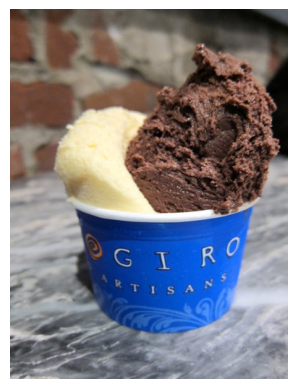

In [30]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

food = mpimg.imread("/content/10_food_classes_10_percent/test/ice_cream/1004744.jpg")
plt.imshow(food)
plt.axis(False)


In [31]:
# Create a function to import an image and resize it to be able to be used with our model
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

In [51]:
food = load_and_prep_image("/content/10_food_classes_10_percent/test/ice_cream/1004744.jpg")
food

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[0.28263304, 0.17282914, 0.09047619],
        [0.28309324, 0.17356943, 0.09121649],
        [0.27340937, 0.167527  , 0.08517408],
        ...,
        [0.352381  , 0.3876751 , 0.42296922],
        [0.36040425, 0.39569837, 0.43099248],
        [0.35916367, 0.3944578 , 0.4297519 ]],

       [[0.2767507 , 0.16582632, 0.09383754],
        [0.2747899 , 0.16890757, 0.09439776],
        [0.28437373, 0.17849138, 0.10398159],
        ...,
        [0.35244095, 0.38773507, 0.42302918],
        [0.35296124, 0.38825536, 0.42354947],
        [0.35920367, 0.39449778, 0.4297919 ]],

       [[0.27931172, 0.17258903, 0.10844339],
        [0.27170867, 0.16532612, 0.10112045],
        [0.26618648, 0.1642257 , 0.09923969],
        ...,
        [0.34593832, 0.380212  , 0.40484187],
        [0.34185678, 0.37547025, 0.4020809 ],
        [0.35996392, 0.3935774 , 0.4291116 ]],

       ...,

       [[0.41962928, 0.43279478, 0.43975756],
        [0.43

In [52]:
tf.round(pred)

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]], dtype=float32)>

In [36]:
class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']